In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [3]:
dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True)

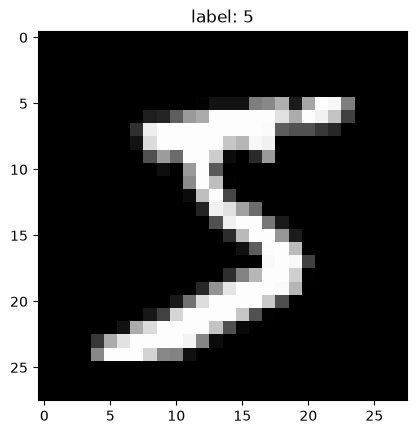

In [4]:
img, label = dataset[0]
plt.imshow(img, cmap="gray")
plt.title(f"label: {label}")
plt.show()

# forward process

In [5]:
import torch

In [6]:
T = 1000
beta = torch.linspace(0.0001, 0.02, T)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

In [7]:
def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)

    sqrt_alpha_bar = torch.sqrt(alpha_bar[t])
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar[t])

    x_t = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise

    return x_t, noise

# MNIST 이미지 : 여러 timestep을 한 줄로 나란히 그리는 코드

In [8]:
import matplotlib.pyplot as plt
from torchvision import transforms

In [9]:
to_tensor = transforms.ToTensor()
img, label = dataset[0]
x0 = to_tensor(img)

In [10]:
timesteps = [0, 50, 100, 250, 500, 750, 999]

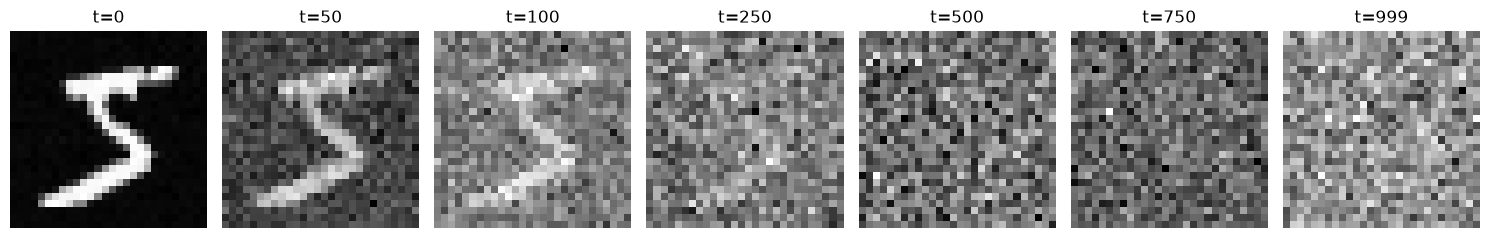

In [11]:
fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 3))

for i, t in enumerate(timesteps):
    x_t, noise = forward_diffusion(x0, t)
    axes[i].imshow(x_t.squeeze(), cmap="gray")
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# 노이즈를 예측하는 네트워크 + 학습 루프

In [12]:
import torch
import torch.nn as nn
import math

In [14]:
# timestep embedding 함수

def sinusoidal_embedding(t, dim=32):
    half_dim = dim 
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim) / half_dim)
    args = t[:, None].float() * freqs[None, :]
    embedding = torch.cat([torch.cin(args), torch.cos(args)], dim=-1)
    return embedding


In [15]:
# 노이즈 예측 네트워크 (아주 작은  CNN)

class SimpleNoisePredictor(nn.Module):
    def __init__(self, time_dim=32):
        super().__init__()
        self.time_mlp = nn.Linear(time_dim, 32)

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 1, 3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x, t_embed):
        t_feat = self.time_mlp(t_embed)
        t_feat = t_feat[:, :, None, None]

        h = self.relu(self.conv1(x))
        h = h + t_feat
        h = self.relu(self.conv2(h))
        out = self.conv3(h)
        return out


In [ ]:
# 학습 루프 (L_simple을 코드로 구현하기)

model = SimpleNoisePredictor()
optimizer = torch.optim.Ada, (model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()